In [ ]:
import pandas as pd

csv_path = "/content/role_challenge_dataset_ground_truth.csv"
df = pd.read_csv(csv_path)


In [ ]:
df.head()


,image_name,ofd_1_x,ofd_1_y,ofd_2_x,ofd_2_y,bpd_1_x,bpd_1_y,bpd_2_x,bpd_2_y
0,000_HC.png,361,12,339,530,481,16,664,318
1,001_HC.png,441,331,368,308,297,247,534,142
2,002_HC.png,318,374,154,406,481,158,558,215
3,003_HC.png,424,105,407,462,305,349,547,363
4,004_HC.png,300,277,611,534,53,452,494,308


In [ ]:
df.columns


Index(['image_name', 'ofd_1_x', 'ofd_1_y', 'ofd_2_x', 'ofd_2_y', 'bpd_1_x',
       'bpd_1_y', 'bpd_2_x', 'bpd_2_y'],
      dtype='object')

In [ ]:
df.shape


(622, 9)

In [ ]:
df.iloc[0]


,0
image_name,000_HC.png
ofd_1_x,361
ofd_1_y,12
ofd_2_x,339
ofd_2_y,530
bpd_1_x,481
bpd_1_y,16
bpd_2_x,664
bpd_2_y,318


In [ ]:
df.describe()


,ofd_1_x,ofd_1_y,ofd_2_x,ofd_2_y,bpd_1_x,bpd_1_y,bpd_2_x,bpd_2_y
count,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000
mean,393.456592,121.631833,389.681672,431.083601,202.736334,274.374598,603.181672,263.049839
std,75.909815,98.286353,99.369648,76.089527,116.856373,75.128164,92.696503,75.541773
min,112.000000,7.000000,18.000000,9.000000,6.000000,9.000000,150.000000,8.000000
25%,359.500000,65.000000,345.500000,410.000000,131.250000,239.250000,568.000000,235.000000
50%,399.000000,92.000000,389.000000,442.000000,176.000000,272.000000,619.000000,271.000000
75%,435.000000,129.750000,432.750000,471.000000,237.000000,306.000000,659.750000,297.750000
max,681.000000,522.000000,757.000000,536.000000,722.000000,509.000000,768.000000,530.000000


In [ ]:
import cv2
import numpy as np

image_path = '/content/004_HC.png'
print("Loading:", image_path)

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

print("Type:", type(img))
print("Dtype:", img.dtype if img is not None else None)
print("Shape:", img.shape if img is not None else None)

if img is None:
    raise ValueError("cv2.imread failed to load the image")

Loading: /content/004_HC.png
Type: <class 'numpy.ndarray'>
Dtype: uint8
Shape: (540, 800)


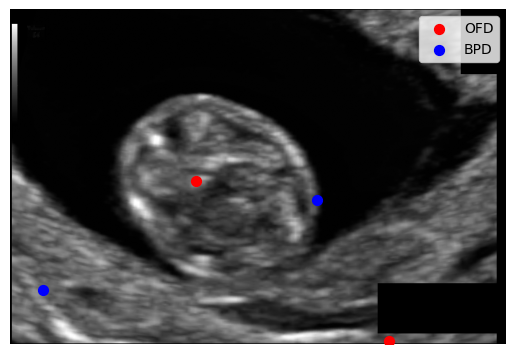

In [ ]:
import cv2
import matplotlib.pyplot as plt

row = df.iloc[4]  # example
img = cv2.imread(f"/content/{row['image_name']}", cv2.IMREAD_GRAYSCALE)

ofd_xs = [row['ofd_1_x'], row['ofd_2_x']]
ofd_ys = [row['ofd_1_y'], row['ofd_2_y']]

bpd_xs = [row['bpd_1_x'], row['bpd_2_x']]
bpd_ys = [row['bpd_1_y'], row['bpd_2_y']]

plt.imshow(img, cmap="gray")
plt.scatter(ofd_xs, ofd_ys, c="red", s=50, label="OFD")
plt.scatter(bpd_xs, bpd_ys, c="blue", s=50, label="BPD")
plt.legend()
plt.axis("off")
plt.show()


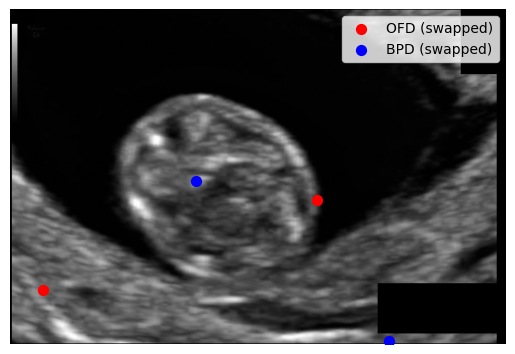

In [ ]:
plt.imshow(img, cmap="gray")

# TREAT BPD AS OFD (swap)
plt.scatter(
    [row['bpd_1_x'], row['bpd_2_x']],
    [row['bpd_1_y'], row['bpd_2_y']],
    c="red", s=50, label="OFD (swapped)"
)

# TREAT OFD AS BPD (swap)
plt.scatter(
    [row['ofd_1_x'], row['ofd_2_x']],
    [row['ofd_1_y'], row['ofd_2_y']],
    c="blue", s=50, label="BPD (swapped)"
)

plt.legend()
plt.axis("off")
plt.show()


In [ ]:
# INTERNAL DEFINITION (based on anatomy, not CSV names)

# OFD = left–right in CSV (actually bpd columns)
ofd_points = [
    (row['bpd_1_x'], row['bpd_1_y']),
    (row['bpd_2_x'], row['bpd_2_y'])
]

# BPD = front–back in CSV (actually ofd columns)
bpd_points = [
    (row['ofd_1_x'], row['ofd_1_y']),
    (row['ofd_2_x'], row['ofd_2_y'])
]


In [ ]:
import numpy as np

def generate_heatmap(height, width, x, y, sigma=5):
    xx, yy = np.meshgrid(np.arange(width), np.arange(height))
    heatmap = np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * sigma**2))
    return heatmap


In [ ]:
H, W = img.shape
heatmaps = np.zeros((4, H, W), dtype=np.float32)

# OFD (front–back)
heatmaps[0] = generate_heatmap(H, W, ofd_points[0][0], ofd_points[0][1])
heatmaps[1] = generate_heatmap(H, W, ofd_points[1][0], ofd_points[1][1])

# BPD (left–right)
heatmaps[2] = generate_heatmap(H, W, bpd_points[0][0], bpd_points[0][1])
heatmaps[3] = generate_heatmap(H, W, bpd_points[1][0], bpd_points[1][1])


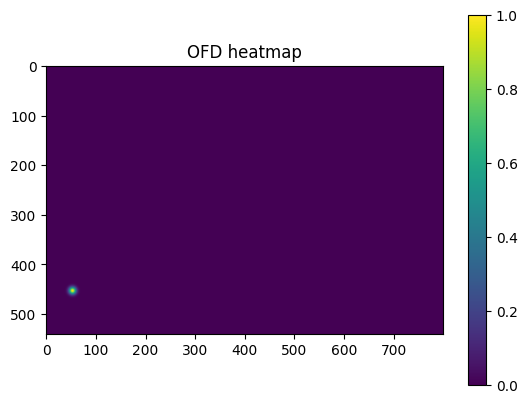

In [ ]:
plt.imshow(heatmaps[0])
plt.title("OFD heatmap")
plt.colorbar()
plt.show()


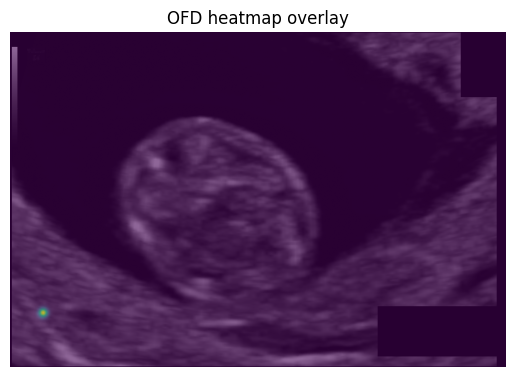

In [ ]:
plt.imshow(img, cmap="gray")
plt.imshow(heatmaps[0], alpha=0.6)
plt.title("OFD heatmap overlay")
plt.axis("off")
plt.show()


In [ ]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import pandas as pd

class FetalLandmarkDataset(Dataset):
    def __init__(self, csv_path, image_size=256, sigma=4):
        self.df = pd.read_csv(csv_path)
        self.image_size = image_size
        self.sigma = sigma

    def __len__(self):
        return len(self.df)

    def _generate_heatmap(self, h, w, x, y):
        xx, yy = np.meshgrid(np.arange(w), np.arange(h))
        heatmap = np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * self.sigma**2))
        return heatmap.astype(np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        img = cv2.imread(row['image_name'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(row['image_name'])

        orig_h, orig_w = img.shape

        # Resize image
        img = cv2.resize(img, (self.image_size, self.image_size))
        img = img.astype(np.float32) / 255.0

        # Scale factors
        sx = self.image_size / orig_w
        sy = self.image_size / orig_h

        # 🔒 SEMANTIC FIX (important)
        ofd_points = [
            (row['bpd_1_x'] * sx, row['bpd_1_y'] * sy),
            (row['bpd_2_x'] * sx, row['bpd_2_y'] * sy),
        ]

        bpd_points = [
            (row['ofd_1_x'] * sx, row['ofd_1_y'] * sy),
            (row['ofd_2_x'] * sx, row['ofd_2_y'] * sy),
        ]

        # Generate heatmaps
        heatmaps = np.zeros((4, self.image_size, self.image_size), dtype=np.float32)

        heatmaps[0] = self._generate_heatmap(self.image_size, self.image_size, *ofd_points[0])
        heatmaps[1] = self._generate_heatmap(self.image_size, self.image_size, *ofd_points[1])
        heatmaps[2] = self._generate_heatmap(self.image_size, self.image_size, *bpd_points[0])
        heatmaps[3] = self._generate_heatmap(self.image_size, self.image_size, *bpd_points[1])

        # To tensors
        img = torch.from_numpy(img).unsqueeze(0)
        heatmaps = torch.from_numpy(heatmaps)

        return img, heatmaps


In [ ]:
dataset = FetalLandmarkDataset(
    csv_path="/content/role_challenge_dataset_ground_truth.csv"
)

img, heatmaps = dataset[4]

print(img.shape)        # (1, 256, 256)
print(heatmaps.shape)   # (4, 256, 256)


torch.Size([1, 256, 256])
torch.Size([4, 256, 256])


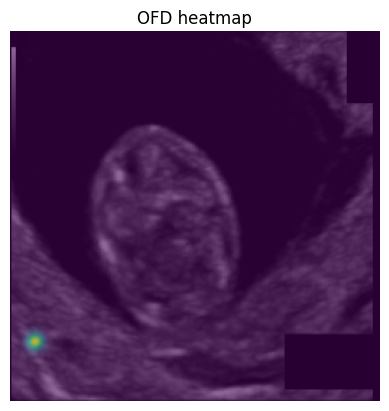

In [ ]:
plt.imshow(img[0], cmap="gray")
plt.imshow(heatmaps[0], alpha=0.6)
plt.title("OFD heatmap")
plt.axis("off")
plt.show()


In [ ]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import pandas as pd

class FetalLandmarkDataset(Dataset):
    def __init__(self, csv_path, image_size=256, sigma=4):
        self.df = pd.read_csv(csv_path)
        self.image_size = image_size
        self.sigma = sigma

    def __len__(self):
        return len(self.df)

    def _generate_heatmap(self, h, w, x, y):
        xx, yy = np.meshgrid(np.arange(w), np.arange(h))
        heatmap = np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * self.sigma**2))
        return heatmap.astype(np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        img = cv2.imread(row['image_name'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(row['image_name'])

        orig_h, orig_w = img.shape

        # Resize image
        img = cv2.resize(img, (self.image_size, self.image_size))
        img = img.astype(np.float32) / 255.0

        # Scale factors
        sx = self.image_size / orig_w
        sy = self.image_size / orig_h

        # 🔒 SEMANTIC FIX (important)
        ofd_points = [
            (row['bpd_1_x'] * sx, row['bpd_1_y'] * sy),
            (row['bpd_2_x'] * sx, row['bpd_2_y'] * sy),
        ]

        bpd_points = [
            (row['ofd_1_x'] * sx, row['ofd_1_y'] * sy),
            (row['ofd_2_x'] * sx, row['ofd_2_y'] * sy),
        ]

        # Generate heatmaps
        heatmaps = np.zeros((4, self.image_size, self.image_size), dtype=np.float32)

        heatmaps[0] = self._generate_heatmap(self.image_size, self.image_size, *ofd_points[0])
        heatmaps[1] = self._generate_heatmap(self.image_size, self.image_size, *ofd_points[1])
        heatmaps[2] = self._generate_heatmap(self.image_size, self.image_size, *bpd_points[0])
        heatmaps[3] = self._generate_heatmap(self.image_size, self.image_size, *bpd_points[1])

        # To tensors
        img = torch.from_numpy(img).unsqueeze(0)
        heatmaps = torch.from_numpy(heatmaps)

        return img, heatmaps


In [ ]:
dataset = FetalLandmarkDataset(
    csv_path="/content/role_challenge_dataset_ground_truth.csv"
)

img, heatmaps = dataset[4]

print(img.shape)        # (1, 256, 256)
print(heatmaps.shape)   # (4, 256, 256)


torch.Size([1, 256, 256])
torch.Size([4, 256, 256])


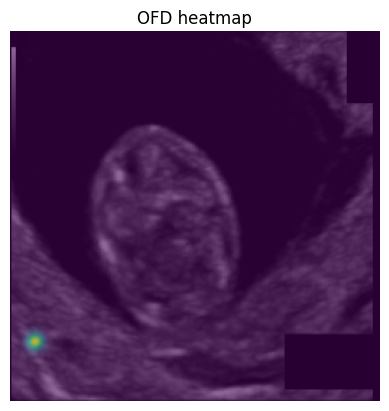

In [ ]:
plt.imshow(img[0], cmap="gray")
plt.imshow(heatmaps[0], alpha=0.6)
plt.title("OFD heatmap")
plt.axis("off")
plt.show()


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # Final layer
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # Bottleneck
        b = self.bottleneck(self.pool4(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)


In [ ]:
model = UNet()
x = torch.randn(1, 1, 256, 256)
y = model(x)

print(y.shape)


torch.Size([1, 4, 256, 256])


In [ ]:
criterion = nn.MSELoss()


In [ ]:
from torch.utils.data import DataLoader, random_split

dataset = FetalLandmarkDataset(
    csv_path="/content/role_challenge_dataset_ground_truth.csv",
    image_size=256,
    sigma=4
)

# 80–20 split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
img = cv2.imread(row['image_name'], cv2.IMREAD_GRAYSCALE)

In [ ]:
import os

image_name = row['image_name']

# If path already contains '/content/', use it
if image_name.startswith("/content/"):
    image_path = image_name
else:
    image_path = os.path.join("/content", image_name)

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(image_path)


In [ ]:
import os

image_name = str(row['image_name']).strip()

# Always construct absolute path
image_path = os.path.join("/content", image_name)

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")


In [ ]:
import os

print(len(os.listdir("/content")))
print(os.listdir("/content")[:10])


4
['.config', '004_HC.png', 'role_challenge_dataset_ground_truth.csv', 'sample_data']


In [ ]:
!unzip /content/images-20260211T124919Z-1-001.zip -d /content/


Archive:  /content/images-20260211T124919Z-1-001.zip
  inflating: /content/images/484_HC.png  
  inflating: /content/images/495_2HC.png  
  inflating: /content/images/475_HC.png  
  inflating: /content/images/483_2HC.png  
  inflating: /content/images/495_3HC.png  
  inflating: /content/images/488_HC.png  
  inflating: /content/images/490_2HC.png  
  inflating: /content/images/495_HC.png  
  inflating: /content/images/483_HC.png  
  inflating: /content/images/487_HC.png  
  inflating: /content/images/499_2HC.png  
  inflating: /content/images/491_HC.png  
  inflating: /content/images/479_HC.png  
  inflating: /content/images/492_HC.png  
  inflating: /content/images/489_HC.png  
  inflating: /content/images/493_HC.png  
  inflating: /content/images/485_HC.png  
  inflating: /content/images/486_2HC.png  
  inflating: /content/images/478_HC.png  
  inflating: /content/images/482_3HC.png  
  inflating: /content/images/498_HC.png  
  inflating: /content/images/482_2HC.png  
  inflating: /c

In [ ]:
!ls /content


004_HC.png  images-20260211T124919Z-1-001.zip	     sample_data
images	    role_challenge_dataset_ground_truth.csv


In [ ]:
!ls /content/images-20260211T124919Z-1-001



ls: cannot access '/content/images-20260211T124919Z-1-001': No such file or directory


In [ ]:
!ls /content/images


000_HC.png   085_HC.png   165_HC.png   246_HC.png   338_HC.png	 424_HC.png
001_HC.png   086_HC.png   166_HC.png   247_HC.png   339_HC.png	 425_2HC.png
002_HC.png   087_HC.png   167_HC.png   248_HC.png   340_2HC.png  425_HC.png
003_HC.png   088_2HC.png  168_HC.png   249_HC.png   340_HC.png	 426_2HC.png
004_HC.png   088_HC.png   169_HC.png   250_HC.png   341_HC.png	 426_3HC.png
005_HC.png   089_HC.png   170_HC.png   251_HC.png   342_HC.png	 426_4HC.png
006_HC.png   090_HC.png   171_HC.png   252_HC.png   343_HC.png	 426_HC.png
007_HC.png   091_HC.png   172_HC.png   253_HC.png   344_HC.png	 427_HC.png
008_HC.png   092_HC.png   173_HC.png   254_HC.png   345_2HC.png  428_HC.png
009_HC.png   093_2HC.png  174_HC.png   255_HC.png   345_HC.png	 429_HC.png
010_2HC.png  093_HC.png   175_HC.png   256_HC.png   346_HC.png	 430_HC.png
010_HC.png   094_HC.png   176_HC.png   257_HC.png   347_HC.png	 431_2HC.png
011_HC.png   095_HC.png   177_HC.png   258_HC.png   348_HC.png	 431_HC.png
012_HC.png   096_H

In [ ]:
import os

image_name = str(row['image_name']).strip()

image_path = os.path.join("/content/images", image_name)

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")


In [ ]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import pandas as pd
import os

class FetalLandmarkDataset(Dataset):
    def __init__(self, csv_path, image_size=256, sigma=4):
        self.df = pd.read_csv(csv_path)
        self.image_size = image_size
        self.sigma = sigma

    def __len__(self):
        return len(self.df)

    def _generate_heatmap(self, h, w, x, y):
        xx, yy = np.meshgrid(np.arange(w), np.arange(h))
        heatmap = np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * self.sigma**2))
        return heatmap.astype(np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_name = str(row['image_name']).strip()
        image_path = os.path.join("/content/images", image_name)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise FileNotFoundError(f"Image not found: {image_path}")

        orig_h, orig_w = img.shape

        img = cv2.resize(img, (self.image_size, self.image_size))
        img = img.astype(np.float32) / 255.0

        sx = self.image_size / orig_w
        sy = self.image_size / orig_h

        # Semantic correction
        ofd_points = [
            (row['bpd_1_x'] * sx, row['bpd_1_y'] * sy),
            (row['bpd_2_x'] * sx, row['bpd_2_y'] * sy),
        ]

        bpd_points = [
            (row['ofd_1_x'] * sx, row['ofd_1_y'] * sy),
            (row['ofd_2_x'] * sx, row['ofd_2_y'] * sy),
        ]

        heatmaps = np.zeros((4, self.image_size, self.image_size), dtype=np.float32)

        heatmaps[0] = self._generate_heatmap(self.image_size, self.image_size, *ofd_points[0])
        heatmaps[1] = self._generate_heatmap(self.image_size, self.image_size, *ofd_points[1])
        heatmaps[2] = self._generate_heatmap(self.image_size, self.image_size, *bpd_points[0])
        heatmaps[3] = self._generate_heatmap(self.image_size, self.image_size, *bpd_points[1])

        img = torch.from_numpy(img).unsqueeze(0)
        heatmaps = torch.from_numpy(heatmaps)

        return img, heatmaps


In [ ]:
dataset = FetalLandmarkDataset(
    csv_path="/content/role_challenge_dataset_ground_truth.csv"
)

train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

for images, heatmaps in train_loader:
    print(images.shape)
    break


torch.Size([8, 1, 256, 256])


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


False
No GPU


In [ ]:
num_epochs = 10  # start small, we can increase later

for epoch in range(num_epochs):

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0

    for images, heatmaps in train_loader:
        images = images.to(device)
        heatmaps = heatmaps.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, heatmaps)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, heatmaps in val_loader:
            images = images.to(device)
            heatmaps = heatmaps.to(device)

            outputs = model(images)
            loss = criterion(outputs, heatmaps)

            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.6f} | "
          f"Val Loss: {val_loss:.6f}")

